# Seamless por CEIL de AWT

Órdenes de `restaurants` en Chile durante la última semana completa (lunes a domingo). El porcentaje de seamless se calcula sobre las órdenes con clasificación `SEAMLESS` válida (`0` o `1`); también se informa la cobertura de esa clasificación.

In [10]:
import pandas as pd
from google.cloud import bigquery
from IPython.display import display

pd.set_option("display.max_rows", None)
PROJECT_ID = "peya-chile"
bq_client = bigquery.Client(project=PROJECT_ID)

c:\Users\pablo.villanueva\.gemini\antigravity\scratch\bigquery_pipeline\github primer repo\lower-ept-y-awt\.venv\Lib\site-packages\google\auth\_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


In [11]:
query = r"""
WITH params AS (
  SELECT
    DATE_SUB(
      DATE_TRUNC(CURRENT_DATE('America/Santiago'), WEEK(MONDAY)),
      INTERVAL 7 DAY
    ) AS week_start,
    DATE_SUB(
      DATE_TRUNC(CURRENT_DATE('America/Santiago'), WEEK(MONDAY)),
      INTERVAL 1 DAY
    ) AS week_end
),
orders AS (
  -- Una fila por orden para evitar duplicarla antes de agregar.
  SELECT
    CAST(l.peya_order_id AS STRING) AS order_id,
    MAX(SAFE_DIVIDE(l.timings.avoidable_wait_time, 60.0)) AS awt_min
  FROM `peya-bi-tools-pro.il_logistics.fact_logistic_orders` AS l
  CROSS JOIN params AS p
  WHERE l.country_code = 'cl'
    AND l.peya_order_id IS NOT NULL
    AND EXISTS (
      SELECT 1
      FROM UNNEST(l.deliveries) AS d
      WHERE d.is_primary = TRUE
    )
    AND l.is_preorder = FALSE
    AND LOWER(l.vendor.vertical_type) = 'restaurants'
    AND DATE(l.created_date_local) BETWEEN p.week_start AND p.week_end
  GROUP BY order_id
),
seamless_by_order AS (
  -- Si una orden tiene etiquetas contradictorias, se deja sin clasificar.
  SELECT
    CAST(n.order_id AS STRING) AS order_id,
    IF(
      COUNT(DISTINCT SAFE_CAST(n.SEAMLESS AS INT64)) = 1,
      MAX(SAFE_CAST(n.SEAMLESS AS INT64)),
      NULL
    ) AS seamless
  FROM `peya-delivery-and-support.automated_tables_reports.non_seamless_reasons` AS n
  CROSS JOIN params AS p
  WHERE n.country_name = 'Chile'
    AND DATE(n.created_date_local) BETWEEN p.week_start AND p.week_end
  GROUP BY order_id
),
metrics AS (
  SELECT
    CAST(CEIL(o.awt_min) AS INT64) AS awt_ceil_min,
    COUNT(*) AS total_orders,
    COUNTIF(s.seamless = 1) AS seamless_orders,
    COUNTIF(s.seamless IN (0, 1)) AS classified_orders
  FROM orders AS o
  LEFT JOIN seamless_by_order AS s USING (order_id)
  GROUP BY awt_ceil_min
)
SELECT
  p.week_start,
  p.week_end,
  m.awt_ceil_min,
  m.total_orders,
  m.seamless_orders,
  m.classified_orders,
  ROUND(100 * SAFE_DIVIDE(m.seamless_orders, m.classified_orders), 2)
    AS seamless_pct,
  ROUND(100 * SAFE_DIVIDE(m.classified_orders, m.total_orders), 2)
    AS classification_coverage_pct
FROM metrics AS m
CROSS JOIN params AS p
ORDER BY m.awt_ceil_min IS NULL, m.awt_ceil_min
"""

seamless_by_awt = bq_client.query(query).to_dataframe()
seamless_by_awt

c:\Users\pablo.villanueva\.gemini\antigravity\scratch\bigquery_pipeline\github primer repo\lower-ept-y-awt\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,week_start,week_end,awt_ceil_min,total_orders,seamless_orders,classified_orders,seamless_pct,classification_coverage_pct
0,2026-08-31,2026-09-06,0,213996,199291,213996,93.13,100.0
1,2026-08-31,2026-09-06,1,76419,70666,76419,92.47,100.0
2,2026-08-31,2026-09-06,2,54944,50555,54944,92.01,100.0
3,2026-08-31,2026-09-06,3,43772,39955,43772,91.28,100.0
4,2026-08-31,2026-09-06,4,36260,32993,36260,90.99,100.0
5,2026-08-31,2026-09-06,5,29604,26643,29604,90.00,100.0
6,2026-08-31,2026-09-06,6,24985,22234,24985,88.99,100.0
7,2026-08-31,2026-09-06,7,21179,18574,21179,87.70,100.0
8,2026-08-31,2026-09-06,8,18001,15620,18001,86.77,100.0
9,2026-08-31,2026-09-06,9,14757,12598,14757,85.37,100.0


In [12]:
if seamless_by_awt.empty:
    print("La consulta no devolvió órdenes para el período.")
else:
    week_start = pd.to_datetime(seamless_by_awt["week_start"].iloc[0]).date()
    week_end = pd.to_datetime(seamless_by_awt["week_end"].iloc[0]).date()
    print(f"Semana analizada: {week_start:%d/%m/%Y}–{week_end:%d/%m/%Y}")
    display(
        seamless_by_awt.style.format(
            {
                "total_orders": "{:,.0f}",
                "seamless_orders": "{:,.0f}",
                "classified_orders": "{:,.0f}",
                "seamless_pct": "{:.2f}%",
                "classification_coverage_pct": "{:.2f}%",
            },
            na_rep="—",
        )
    )

Semana analizada: 31/08/2026–06/09/2026


,week_start,week_end,awt_ceil_min,total_orders,seamless_orders,classified_orders,seamless_pct,classification_coverage_pct
0,2026-08-31,2026-09-06,0,"213,996","199,291","213,996",93.13%,100.00%
1,2026-08-31,2026-09-06,1,"76,419","70,666","76,419",92.47%,100.00%
2,2026-08-31,2026-09-06,2,"54,944","50,555","54,944",92.01%,100.00%
3,2026-08-31,2026-09-06,3,"43,772","39,955","43,772",91.28%,100.00%
4,2026-08-31,2026-09-06,4,"36,260","32,993","36,260",90.99%,100.00%
5,2026-08-31,2026-09-06,5,"29,604","26,643","29,604",90.00%,100.00%
6,2026-08-31,2026-09-06,6,"24,985","22,234","24,985",88.99%,100.00%
7,2026-08-31,2026-09-06,7,"21,179","18,574","21,179",87.70%,100.00%
8,2026-08-31,2026-09-06,8,"18,001","15,620","18,001",86.77%,100.00%
9,2026-08-31,2026-09-06,9,"14,757","12,598","14,757",85.37%,100.00%


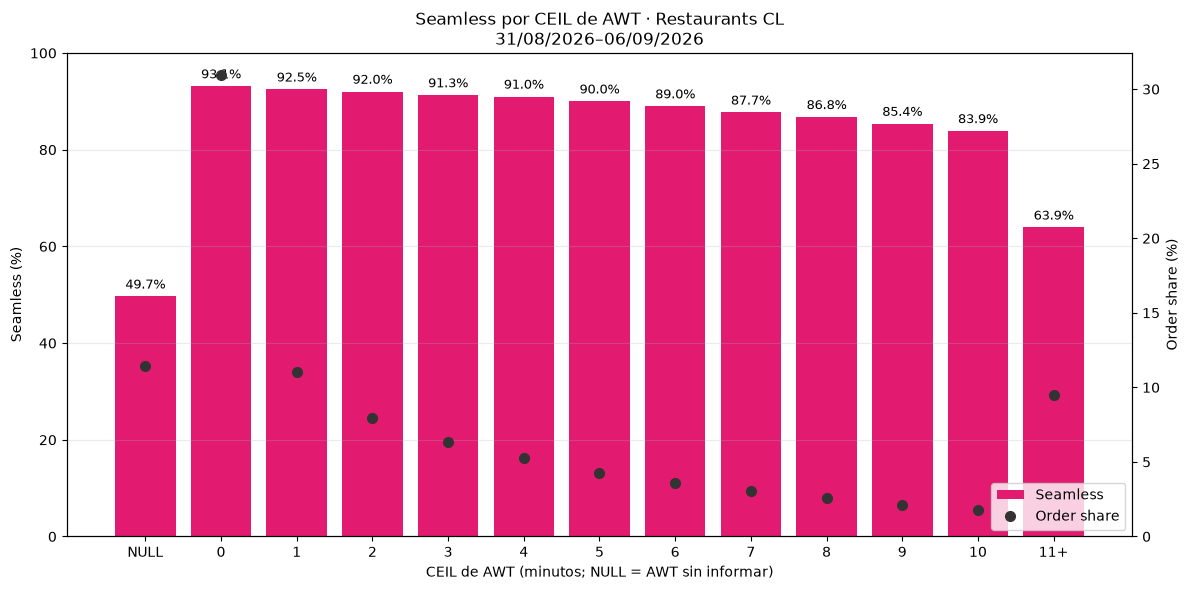

In [13]:
import matplotlib.pyplot as plt

bucket_order = ["NULL"] + [str(value) for value in range(11)] + ["11+"]
plot_data = seamless_by_awt.copy()
plot_data["awt_ceil_min"] = pd.to_numeric(
    plot_data["awt_ceil_min"], errors="coerce"
)
plot_data = plot_data.loc[
    plot_data["awt_ceil_min"].isna()
    | plot_data["awt_ceil_min"].ge(0)
].copy()
has_awt = plot_data["awt_ceil_min"].notna()
plot_data["awt_bucket"] = "NULL"
plot_data.loc[has_awt, "awt_bucket"] = (
    plot_data.loc[has_awt, "awt_ceil_min"]
    .astype("Int64")
    .astype("string")
)
plot_data.loc[plot_data["awt_ceil_min"].ge(11), "awt_bucket"] = "11+"

plot_data = (
    plot_data.groupby("awt_bucket", observed=True)[
        ["total_orders", "seamless_orders", "classified_orders"]
    ]
    .sum()
    .reindex(bucket_order, fill_value=0)
)
plot_data["seamless_pct"] = (
    100
    * plot_data["seamless_orders"]
    / plot_data["classified_orders"].replace(0, pd.NA)
)
plot_data["order_share_pct"] = (
    100 * plot_data["total_orders"] / plot_data["total_orders"].sum()
)
plot_values = plot_data["seamless_pct"].to_numpy(
    dtype=float, na_value=float("nan")
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(
    plot_data.index,
    plot_values,
    color="#e21b70",
    label="Seamless",
)
ax.set(
    title=(
        f"Seamless por CEIL de AWT · Restaurants CL\n"
        f"{week_start:%d/%m/%Y}–{week_end:%d/%m/%Y}"
    ),
    xlabel="CEIL de AWT (minutos; NULL = AWT sin informar)",
    ylabel="Seamless (%)",
)
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.25)

# Order share como puntos, sin línea de conexión, sobre el eje secundario.
ax_share = ax.twinx()
share_points = ax_share.plot(
    plot_data.index,
    plot_data["order_share_pct"],
    color="#333333",
    marker="o",
    markersize=7,
    linestyle="None",
    label="Order share",
)[0]
ax_share.set_ylabel("Order share (%)")
ax_share.set_ylim(bottom=0)
ax.legend(
    [bars, share_points],
    ["Seamless", "Order share"],
    loc="lower right",
)

for bar, value in zip(bars, plot_values):
    if pd.notna(value):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 1,
            f"{value:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.tight_layout()
plt.show()

In [15]:
import json
import pandas as pd

with open("vendor_rules.txt", encoding="utf-8") as file:
    payload = json.load(file)

vendor_rules = pd.json_normalize(
    payload["rules"],
    sep="_",
)

pd.set_option("display.max_columns", None)

print(vendor_rules.shape)
display(vendor_rules.head())

vendor_rules.head()

(220, 67)


,title,ruleType,deploymentType,limit,enabled,vendorGrades,vendorMaturities,vendorTypes,priority,verticals,configuredActions,ruleVersion,escalations,id,createdAt,updatedAt,globalEntityId,countryCode,issueDetectorParameters_rangeType,issueDetectorParameters_rangeValue,issueDetectorParameters_orderSampleMinimum,issueDetectorParameters_orderSampleMaximum,issueDetectorParameters_failureRateMinimum,issueDetectorParameters_failureRateMaximum,issueDetectorParameters_delay,issueDetectorParameters_ruleType,vendorHadOrdersInLast28Days,issueDetectorParameters_minimumWaitingOrders,issueDetectorParameters_calculationUntilEvent,issueDetectorParameters_minimumWaitingTime,vendorOrderFailurePerformanceGrades,targetedChains,issueDetectorParameters_orderFailureReasons,issueDetectorParameters_orderSampleSize,issueDetectorParameters_minPercentFailRate,issueDetectorParameters_maxPercentFailRate,issueDetectorParameters_orderDeliveryTypes,vendorAwtPerformanceGrades,vendorTags,issueDetectorParameters_orderStackingType,issueDetectorParameters_minimumAvoidableWaitingTime,issueDetectorParameters_minimumNumberOfCouriersWaitingAtVendor,issueDetectorParameters_minimumQueuedOrders,ruleScheduleTimeSlot_start,ruleScheduleTimeSlot_end,issueDetectorParameters_unavailableDurationMinimumMinutes,issueDetectorParameters_availabilityReasons,issueDetectorParameters_unavailableRateMinimum,issueDetectorParameters_unavailableRateMaximum,execution_id,execution_state,execution_detectedIssues,execution_deployedIssues,excludedChains,issueDetectorParameters_waitingTimeAtVendor,issueDetectorParameters_customerContactRateMinimum,issueDetectorParameters_customerContactRateMaximum,issueDetectorParameters_customerContactOrdersPercentageMinimum,issueDetectorParameters_customerContactOrdersPercentageMaximum,issueDetectorParameters_customerContactRateReasons,ruleScheduleWeekDays_monday,ruleScheduleWeekDays_tuesday,ruleScheduleWeekDays_wednesday,ruleScheduleWeekDays_thursday,ruleScheduleWeekDays_friday,ruleScheduleWeekDays_saturday,ruleScheduleWeekDays_sunday
0,Push notification AB test,UNREACHABLE_REALTIME,AUTOMATIC,10000,True,"[AAA, AA, A, B, C, D, NA]","[MATURE_VENDOR, NEW_VENDOR]","[GO_CLIENT_DIRECT_POS, GO_CLIENT_INDIRECT_POS,...",1,"[restaurants, groceries, flowers, cosmetics, h...","[{'actionType': 'SEND_PUSH_NOTIFICATION', 'con...",2.0,"[{'issueDetectorParameters': {'rangeType': '',...",e79990,1773680162267,1773680162267,PY_CL,CL,,0,0,0,0,0,2.0,UNREACHABLE_REALTIME,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Level 2 - Supermarket (AAA & AA),QC_SATURATION_REALTIME,AUTOMATIC,10000,True,"[AAA, AA]","[MATURE_VENDOR, NEW_VENDOR]",[PELICAN],1,[supermarket],"[{'actionType': 'TURN_ON_HIGH_DEMAND_MODE', 'c...",NaN,"[{'issueDetectorParameters': {'rangeType': '',...",3d57d0,1788785593293,1788810097796,PY_CL,CL,,0,0,0,0,0,NaN,QC_SATURATION_REALTIME,"[Yes, No]",3.0,ASSEMBLY_STARTED,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,VFR_ITEM_UNAVAILABLE_QC_MACRO_CAPA_3,ORDER_FAILURE_REALTIME,AUTOMATIC,10000,True,"[AAA, AA, A, B, C, D, NA]","[MATURE_VENDOR, NEW_VENDOR]","[GO_CLIENT_DIRECT_POS, GO_CLIENT_INDIRECT_POS,...",1,"[groceries, flowers, cosmetics, health_supplem...","[{'actionType': 'CLOSE_VENDOR_TEMPORARILY', 'c...",2.0,[{'issueDetectorParameters': {'rangeType': 'HO...,da1205,1779212110450,1779214881414,PY_CL,CL,HOUR,6,0,0,0,0,NaN,ORDER_FAILURE_REALTIME,"[Yes, No]",NaN,NaN,NaN,"[low_order_failure_rate, medium_order_failure_...","[0011r00002VoI36, 0016900002ajxxM, 0011r00002V...",[ITEM_UNAVAILABLE],8.0,30.0,100.0,"[OD, VD, PU]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NIU sushi special date all grades,AWT_REALTIME,AUTOMATIC,10000,True,"[AAA, AA, A, B, C, D, NA]","[MATURE_VENDOR, NEW_

,title,ruleType,deploymentType,limit,enabled,vendorGrades,vendorMaturities,vendorTypes,priority,verticals,configuredActions,ruleVersion,escalations,id,createdAt,updatedAt,globalEntityId,countryCode,issueDetectorParameters_rangeType,issueDetectorParameters_rangeValue,issueDetectorParameters_orderSampleMinimum,issueDetectorParameters_orderSampleMaximum,issueDetectorParameters_failureRateMinimum,issueDetectorParameters_failureRateMaximum,issueDetectorParameters_delay,issueDetectorParameters_ruleType,vendorHadOrdersInLast28Days,issueDetectorParameters_minimumWaitingOrders,issueDetectorParameters_calculationUntilEvent,issueDetectorParameters_minimumWaitingTime,vendorOrderFailurePerformanceGrades,targetedChains,issueDetectorParameters_orderFailureReasons,issueDetectorParameters_orderSampleSize,issueDetectorParameters_minPercentFailRate,issueDetectorParameters_maxPercentFailRate,issueDetectorParameters_orderDeliveryTypes,vendorAwtPerformanceGrades,vendorTags,issueDetectorParameters_orderStackingType,issueDetectorParameters_minimumAvoidableWaitingTime,issueDetectorParameters_minimumNumberOfCouriersWaitingAtVendor,issueDetectorParameters_minimumQueuedOrders,ruleScheduleTimeSlot_start,ruleScheduleTimeSlot_end,issueDetectorParameters_unavailableDurationMinimumMinutes,issueDetectorParameters_availabilityReasons,issueDetectorParameters_unavailableRateMinimum,issueDetectorParameters_unavailableRateMaximum,execution_id,execution_state,execution_detectedIssues,execution_deployedIssues,excludedChains,issueDetectorParameters_waitingTimeAtVendor,issueDetectorParameters_customerContactRateMinimum,issueDetectorParameters_customerContactRateMaximum,issueDetectorParameters_customerContactOrdersPercentageMinimum,issueDetectorParameters_customerContactOrdersPercentageMaximum,issueDetectorParameters_customerContactRateReasons,ruleScheduleWeekDays_monday,ruleScheduleWeekDays_tuesday,ruleScheduleWeekDays_wednesday,ruleScheduleWeekDays_thursday,ruleScheduleWeekDays_friday,ruleScheduleWeekDays_saturday,ruleScheduleWeekDays_sunday
0,Push notification AB test,UNREACHABLE_REALTIME,AUTOMATIC,10000,True,"[AAA, AA, A, B, C, D, NA]","[MATURE_VENDOR, NEW_VENDOR]","[GO_CLIENT_DIRECT_POS, GO_CLIENT_INDIRECT_POS,...",1,"[restaurants, groceries, flowers, cosmetics, h...","[{'actionType': 'SEND_PUSH_NOTIFICATION', 'con...",2.0,"[{'issueDetectorParameters': {'rangeType': '',...",e79990,1773680162267,1773680162267,PY_CL,CL,,0,0,0,0,0,2.0,UNREACHABLE_REALTIME,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Level 2 - Supermarket (AAA & AA),QC_SATURATION_REALTIME,AUTOMATIC,10000,True,"[AAA, AA]","[MATURE_VENDOR, NEW_VENDOR]",[PELICAN],1,[supermarket],"[{'actionType': 'TURN_ON_HIGH_DEMAND_MODE', 'c...",NaN,"[{'issueDetectorParameters': {'rangeType': '',...",3d57d0,1788785593293,1788810097796,PY_CL,CL,,0,0,0,0,0,NaN,QC_SATURATION_REALTIME,"[Yes, No]",3.0,ASSEMBLY_STARTED,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,VFR_ITEM_UNAVAILABLE_QC_MACRO_CAPA_3,ORDER_FAILURE_REALTIME,AUTOMATIC,10000,True,"[AAA, AA, A, B, C, D, NA]","[MATURE_VENDOR, NEW_VENDOR]","[GO_CLIENT_DIRECT_POS, GO_CLIENT_INDIRECT_POS,...",1,"[groceries, flowers, cosmetics, health_supplem...","[{'actionType': 'CLOSE_VENDOR_TEMPORARILY', 'c...",2.0,[{'issueDetectorParameters': {'rangeType': 'HO...,da1205,1779212110450,1779214881414,PY_CL,CL,HOUR,6,0,0,0,0,NaN,ORDER_FAILURE_REALTIME,"[Yes, No]",NaN,NaN,NaN,"[low_order_failure_rate, medium_order_failure_...","[0011r00002VoI36, 0016900002ajxxM, 0011r00002V...",[ITEM_UNAVAILABLE],8.0,30.0,100.0,"[OD, VD, PU]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NIU sushi special date all grades,AWT_REALTIME,AUTOMATIC,10000,True,"[AAA, AA, A, B, C, D, NA]","[MATURE_VENDOR, NEW_

In [16]:
usage_by_rule_type = (
    vendor_rules
    .groupby("ruleType")
    .apply(lambda group: group.notna().sum())
    .T
)

display(usage_by_rule_type)

ruleType,AVAILABILITY,AWT_HISTORICAL,AWT_REALTIME,CUSTOMER_CONTACT_RATE,ORDER_FAILURE,ORDER_FAILURE_REALTIME,QC_SATURATION_REALTIME,UNREACHABLE_REALTIME
title,11,1,103,1,3,94,6,1
deploymentType,11,1,103,1,3,94,6,1
limit,11,1,103,1,3,94,6,1
enabled,11,1,103,1,3,94,6,1
vendorGrades,11,1,103,1,3,94,6,1
vendorMaturities,11,1,103,1,3,94,6,1
vendorTypes,11,1,103,1,3,94,6,1
priority,11,1,103,1,3,94,6,1
verticals,11,1,103,1,3,94,6,1
configuredActions,11,1,103,1,3,94,6,1


In [17]:
awt_rules = vendor_rules[
    vendor_rules["ruleType"].str.contains("AWT", na=False)
].copy()

awt_rules = awt_rules.dropna(axis=1, how="all")

display(awt_rules)

,title,ruleType,deploymentType,limit,enabled,vendorGrades,vendorMaturities,vendorTypes,priority,verticals,configuredActions,ruleVersion,escalations,id,createdAt,updatedAt,globalEntityId,countryCode,issueDetectorParameters_rangeType,issueDetectorParameters_rangeValue,issueDetectorParameters_orderSampleMinimum,issueDetectorParameters_orderSampleMaximum,issueDetectorParameters_failureRateMinimum,issueDetectorParameters_failureRateMaximum,issueDetectorParameters_ruleType,vendorHadOrdersInLast28Days,targetedChains,vendorAwtPerformanceGrades,vendorTags,issueDetectorParameters_orderStackingType,issueDetectorParameters_minimumAvoidableWaitingTime,issueDetectorParameters_minimumNumberOfCouriersWaitingAtVendor,issueDetectorParameters_minimumQueuedOrders,ruleScheduleTimeSlot_start,ruleScheduleTimeSlot_end,execution_id,execution_state,execution_detectedIssues,execution_deployedIssues,excludedChains,issueDetectorParameters_waitingTimeAtVendor,ruleScheduleWeekDays_monday,ruleScheduleWeekDays_tuesday,ruleScheduleWeekDays_wednesday,ruleScheduleWeekDays_thursday,ruleScheduleWeekDays_friday,ruleScheduleWeekDays_saturday,ruleScheduleWeekDays_sunday
3,NIU sushi special date all grades,AWT_REALTIME,AUTOMATIC,10000,True,"[AAA, AA, A, B, C, D, NA]","[MATURE_VENDOR, NEW_VENDOR]","[GO_CLIENT_DIRECT_POS, GO_CLIENT_INDIRECT_POS,...",1,[restaurants],"[{'actionType': 'TURN_ON_HIGH_DEMAND_MODE', 'c...",2.0,"[{'issueDetectorParameters': {'rangeType': '',...",63f4bf,1775148054038,1786020236051,PY_CL,CL,,0,0,0,0,0,AWT_REALTIME,"[Yes, No]",[0011r00002VoI4m],"[low_awt, medium_awt, high_awt]",[awt_hdm_city_exp_vga_2293_pilot],ALL,4.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NIU sushi special date all grades v2,AWT_REALTIME,AUTOMATIC,10000,True,"[AAA, AA, A, B, C, D, NA]","[MATURE_VENDOR, NEW_VENDOR]","[GO_CLIENT_DIRECT_POS, GO_CLIENT_INDIRECT_POS,...",2,[restaurants],"[{'actionType': 'TURN_ON_HIGH_DEMAND_MODE', 'c...",2.0,"[{'issueDetectorParameters': {'rangeType': '',...",bcf863,1775831050324,1786020241506,PY_CL,CL,,0,0,0,0,0,AWT_REALTIME,"[Yes, No]",[0011r00002VoI4m],"[low_awt, medium_awt, high_awt]",[awt_hdm_city_exp_vga_2293_pilot],ALL,4.0,1.0,4.0,17:00,21:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,NIU sushi special dates all grades v3,AWT_REALTIME,AUTOMATIC,10000,True,"[AAA, AA, A, B, C, D, NA]","[MATURE_VENDOR, NEW_VENDOR]","[GO_CLIENT_DIRECT_POS, GO_CLIENT_INDIRECT_POS,...",3,[restaurants],"[{'actionType': 'TURN_ON_HIGH_DEMAND_MODE', 'c...",2.0,"[{'issueDetectorParameters': {'rangeType': '',...",fd4de6,1776982258041,1786020246052,PY_CL,CL,,0,0,0,0,0,AWT_REALTIME,"[Yes, No]",[0011r00002VoI4m],"[low_awt, medium_awt, high_awt]",[awt_hdm_city_exp_vga_2293_pilot],ALL,4.0,2.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,McDonald's HDM v1,AWT_REALTIME,AUTOMATIC,10000,True,"[AAA, AA, A]","[MATURE_VENDOR, NEW_VENDOR]","[GO_CLIENT_DIRECT_POS, GO_CLIENT_INDIRECT_POS,...",4,[restaurants],"[{'actionType': 'TURN_ON_HIGH_DEMAND_MODE', 'c...",2.0,"[{'issueDetectorParameters': {'rangeType': '',...",d50582,1777059642046,1786020255711,PY_CL,CL,,0,0,0,0,0,AWT_REALTIME,"[Yes, No]",[0011r00002VoHw4],"[low_awt, medium_awt, high_awt]",[awt_hdm_city_exp_vga_2293_pilot],ALL,4.0,1.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,McDonald's HDM v2,AWT_REALTIME,AUTOMATIC,10000,True,"[AAA, AA, A]","[MATURE_VENDOR, NEW_VENDOR]","[GO_CLIENT_DIRECT_POS, GO_CLIENT_INDIRECT_POS,...",5,[restaurants],"[{'actionType': 'TURN_ON_HIGH_DEMAND_MODE', 'c...",2.0,"[{'issueDetectorParameters': {'rangeType': '',...",2ec9ef,1777059762195,1786020260035,PY_CL,CL,,0,0,0,0,0,AWT_REALTIME,"[Yes, No]",[0011r00002VoHw4],"[low_awt, medium_awt, high_awt]",[awt_hdm_city_exp_vga_2293_pilot],ALL,4.0,2.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,Papa John's Melt Under AAA,AWT_REALTIME,AUTOMATIC,10000,True,[AAA],"[MATURE_VENDOR, NEW_VENDOR]","[GO_CLIENT_DIRECT_POS, GO_CLIENT_INDIRECT_POS,...",6,[restaurants